In [1]:
%load_ext autoreload
%autoreload 2

In [10]:
from collections import defaultdict
import os
import pprint

import hydra
from omegaconf import OmegaConf
from einops import rearrange
import torch
import lightning.pytorch as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid', font_scale=1.3, palette=sns.color_palette('husl'),)

from conf import conf
from dafm import datasets, models, utils

In [3]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [4]:
with hydra.initialize(version_base=utils.HYDRA_INIT['version_base'], config_path='../conf'):
    cfg = hydra.compose(utils.HYDRA_INIT['config_name'], overrides=[
        'model=FlowMatching', 'model/diffusion_path=ConditionalOptimalTransport',
        'dataset=Lorenz96', 'dataset.time_step_count=100',
        'dataset.time_step_size=.01',
        'dataset.model_std=0',
    ])
    engine = conf.get_engine()
    conf.orm.create_all(engine)
    with conf.sa.orm.Session(engine) as db:
        cfg = conf.orm.instantiate_and_insert_config(db, OmegaConf.to_container(cfg, resolve=True))
        pprint.pp(cfg)

Conf(root_dir='/root/workspace/GitHub/Data-Assimilation-Flow-Matching',
     out_dir='/root/workspace/out/dafm',
     run_subdir='runs',
     prediction_filename='trajectories.parquet',
     device='cuda',
     alt_id='cxcvhtv2',
     rng_seed=2376999025,
     fit=True,
     id=49,
     dataset=Lorenz96(predicted_state_count=1000,
                      time_step_count=100,
                      time_step_count_drop_first=0,
                      time_step_size=0.01,
                      sa_inheritance='Lorenz96',
                      id=15,
                      model_std=0.0,
                      observation_std=0.5,
                      true_state_initial_condition_mean=4.0,
                      true_state_initial_condition_std=2.0,
                      predicted_state_initial_condition_std=0.2,
                      predicted_state_model_std=1.0,
                      state_dimension=10,
                      forcing=8.0),
     model=FlowMatching(ignore_observations=False,
   

In [5]:
# pl.seed_everything(cfg.rng_seed)
# with pl.utilities.seed.isolate_rng():
dynamics = datasets.get_dynamics_dataset(cfg.dataset, cfg.device)

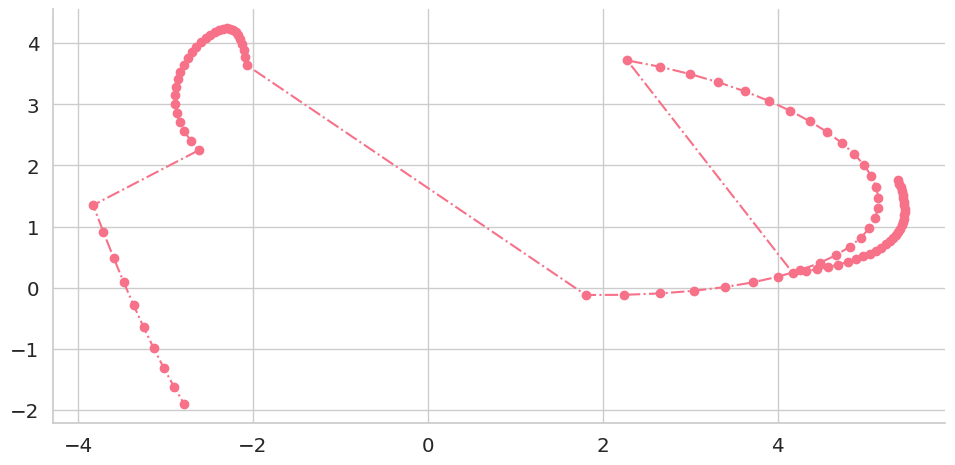

In [34]:
data = dynamics.data.copy()
data['true_state'] = rearrange(
    data['true_state'],
    't 1 dim -> t dim',
)
data['observation'] = rearrange(
    data['observation'],
    't 1 dim -> t dim',
)
data['true_state'] = pd.DataFrame(
    data['true_state'].cpu().numpy(),
    index=range(data['true_state'].shape[0]),
    columns=[f'true_state_dim_{d}' for d in range(dynamics.cfg.state_dimension)],
)
data['observation'] = pd.DataFrame(
    data['observation'].cpu().numpy(),
    index=range(data['observation'].shape[0]),
    columns=[f'observation_dim_{d}' for d in range(dynamics.cfg.state_dimension)],
)
data['times'] = pd.DataFrame(
    data['times'].cpu().numpy(),
    index=range(data['times'].shape[0]),
    columns=['Time'],
)
df = pd.concat([data[k] for k in ('times', 'true_state', 'observation')], axis=1)
plot = (
    sns.FacetGrid(
        data=df,
        height=5,
        aspect=2,
        # hue='Time',
        # hue='Source',
        # style='Source',
        # markers=True,
        # hue_order=['true_state', 'predicted_state_mean'],
    )
    # .set(ylim=(-1.5, 1.5))
)
for (row, col, hue), data in plot.facet_data():
    ax = plot.axes[row][col]
    ax.plot('true_state_dim_0', 'true_state_dim_1', 'o-.', data=data)
# sns.move_legend(
#     plot,
#     loc='upper center',
#     ncol=min(len(df_line['Source'].unique()), 3),
#     title='',
#     bbox_to_anchor=(.455, 1.12),
#     frameon=True,
#     fancybox=True,
# )

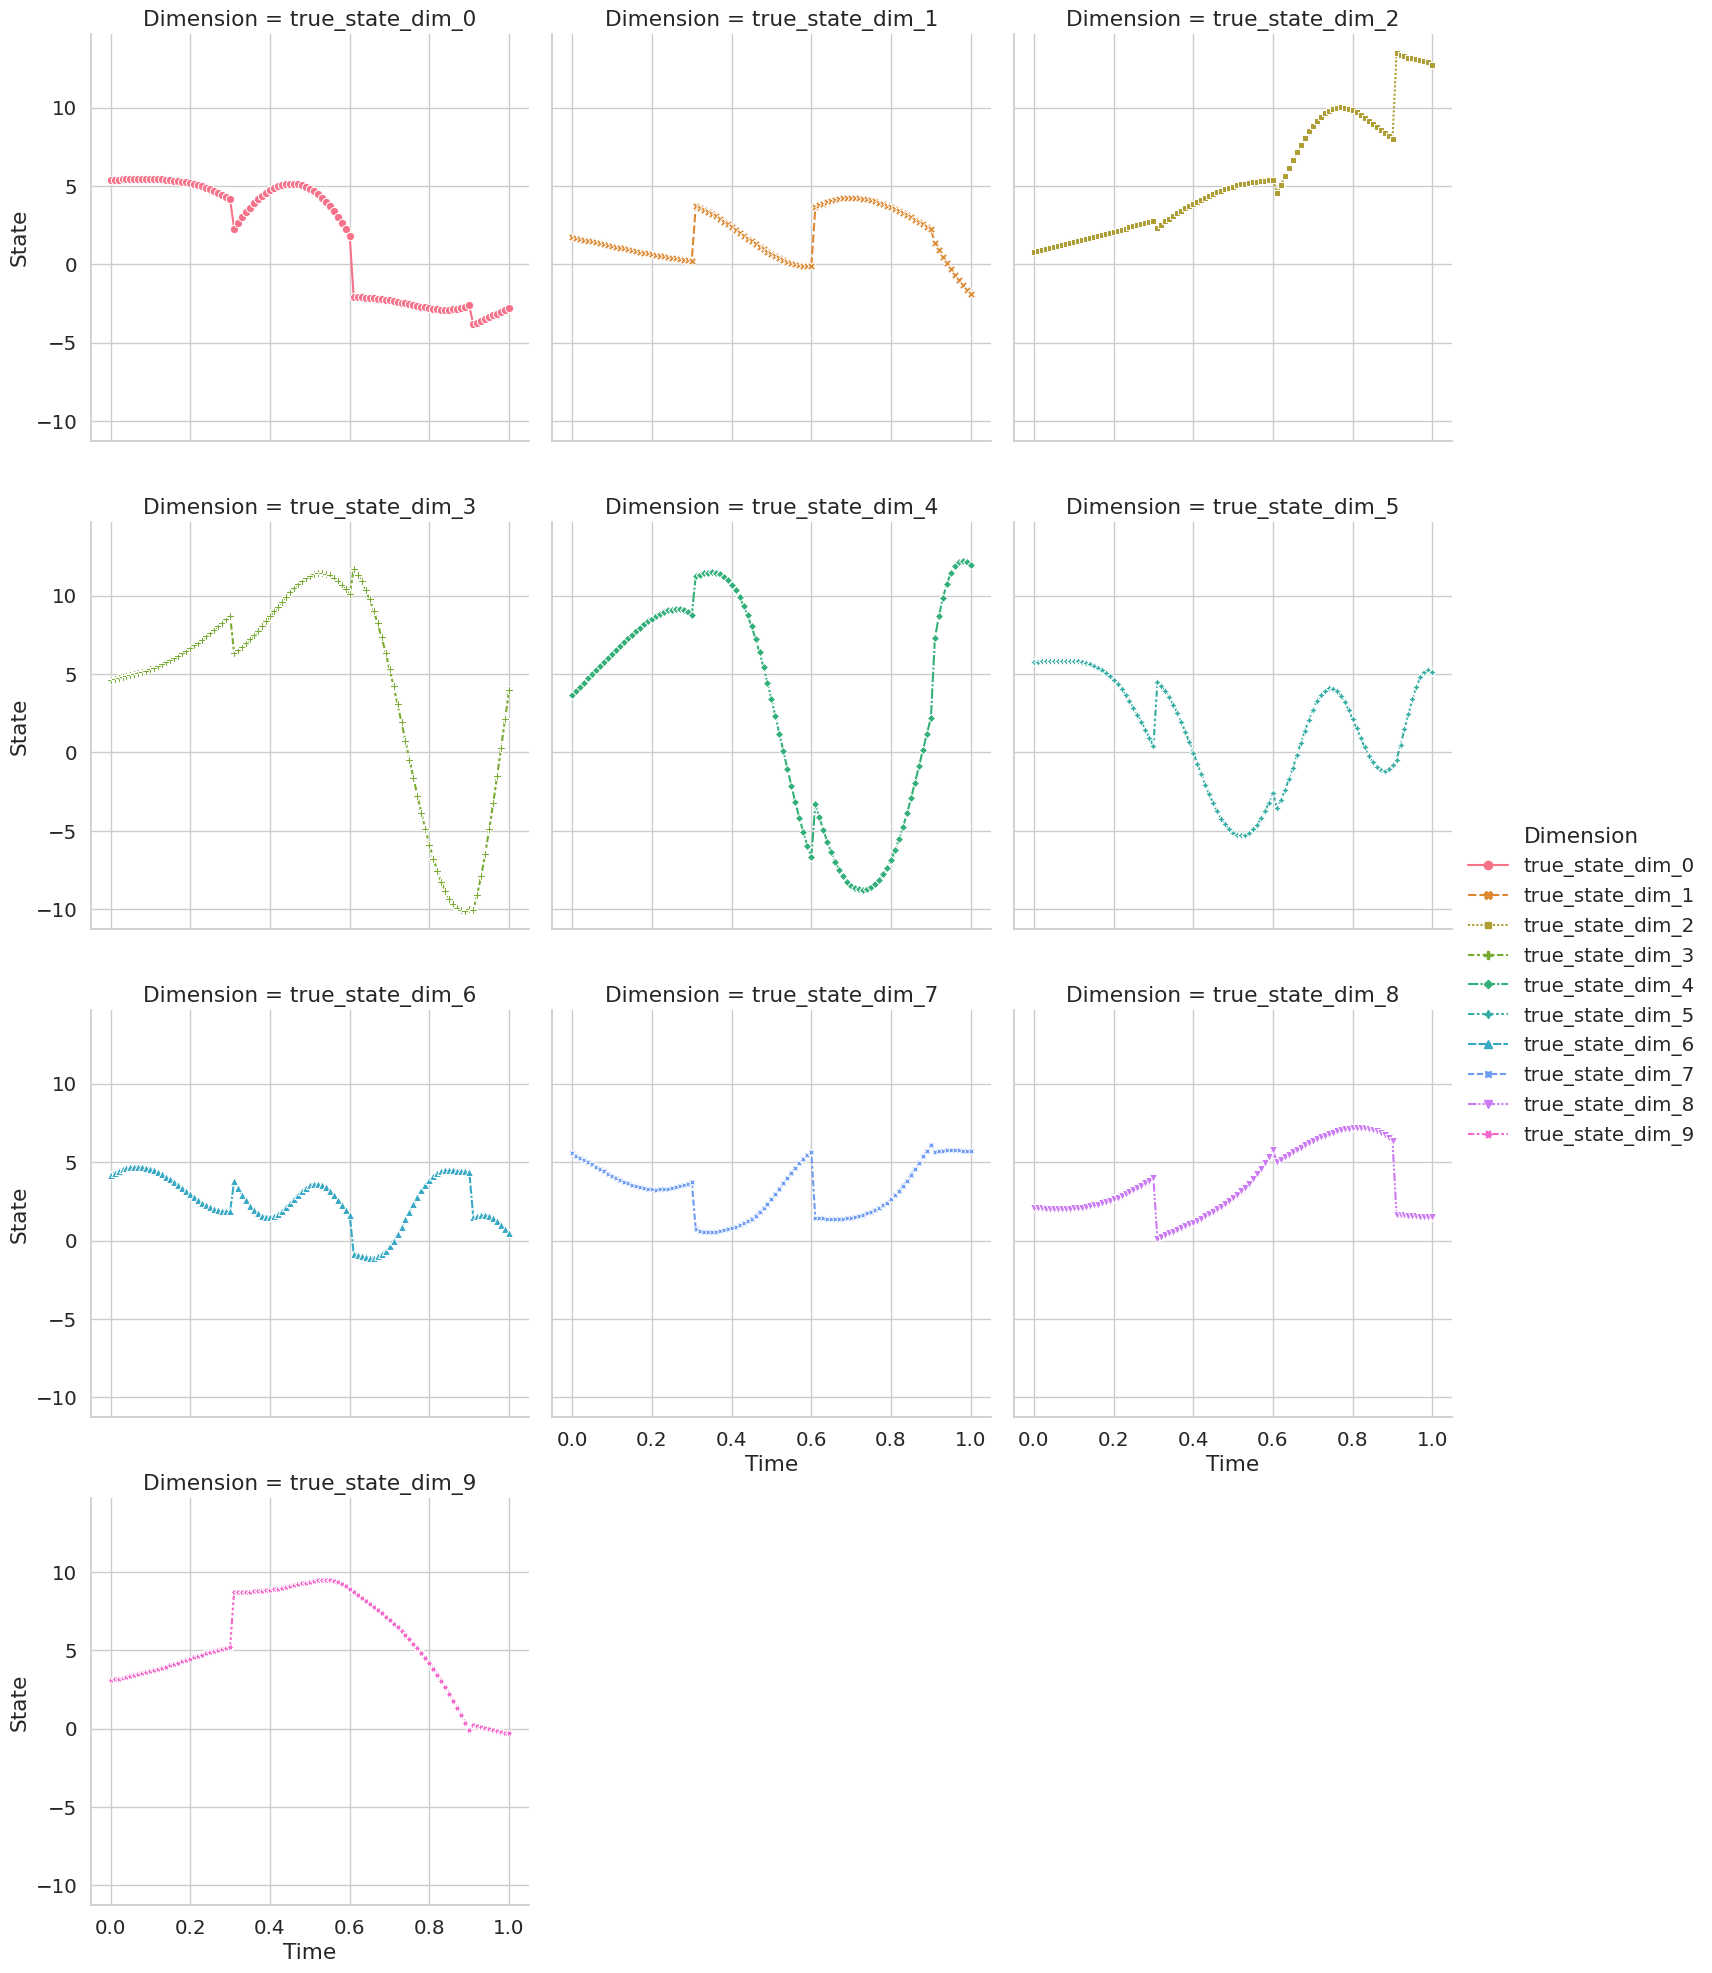

In [41]:
plot = (
    sns.relplot(
        data=df.melt(id_vars=['Time'], value_vars=df.columns[df.columns.str.startswith('true_state')], var_name='Dimension', value_name='State'),
        kind='line',
        x='Time',
        y='State',
        col='Dimension',
        hue='Dimension',
        style='Dimension',
        markers=True,
        col_wrap=3,
    )
)